# 7. 연습 문제

### 연습 문제 1
와인 품질 데이터셋(`load_wine()`)으로 로지스틱 회귀와 결정 트리를 학습하고 성능을 비교하세요.


In [47]:
# 환경 설정 #

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

# 한글 폰트 
matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Windows
# matplotlib.rcParams['font.family'] = 'AppleGothic'   # macOS
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.datasets import load_breast_cancer, load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

print('라이브러리 임포트 완료!')
print(f'NumPy 버전: {np.__version__}')
print(f'Pandas 버전: {pd.__version__}')


라이브러리 임포트 완료!
NumPy 버전: 2.4.3
Pandas 버전: 2.3.0


In [48]:
# 와인 품질 데이터 불러오기
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print('=== 와인 품질 데이터 정보 ===')
print(f'데이터 크기: {X_wine.shape}')
print(f'클래스: {wine.target_names}')

# 학습/테스트 분리 (test_size=0.2, random_state=42)
# X_train_w, X_test_w, y_train_w, y_test_w = ...
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# 표준화
scaler_w = StandardScaler()
X_train_ws = scaler_w.fit_transform(X_train_w)
X_test_ws = scaler_w.transform(X_test_w)

print('\n=== 데이터 분리 완료 ===')
print(f'학습 데이터: {X_train_ws.shape}')
print(f'테스트 데이터: {X_test_ws.shape}')
print()
print(f'표준화 전 특성 범위: {X_train_w[:, 0].min():.2f} ~ {X_train_w[:, 0].max():.2f}')
print(f'표준화 후 특성 범위: {X_train_ws[:, 0].min():.2f} ~ {X_train_ws[:, 0].max():.2f}')

# 로지스틱 회귀와 결정트리 정확도 비교
print('\n=== 로지스틱 회귀와 결정트리 정확도 비교 ===')
# 로지스틱 회귀 학습 및 정확도 출력
lr_wine = LogisticRegression(max_iter=1000, random_state=42)
lr_wine.fit(X_train_ws, y_train_w)
y_pred_w = lr_wine.predict(X_test_ws)
lr_val = accuracy_score(y_test_w, y_pred_w)
print(f'로지스틱 회귀 정확도(max_iter=1000): {lr_val*100:.2f}%')

# 결정 트리 학습 및 정확도 출력 (max_depth=5)
dt_wine = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_wine.fit(X_train_w, y_train_w)
y_dt_pred = dt_wine.predict(X_test_w)
dt_val = accuracy_score(y_test_w, y_dt_pred)
print(f'결정 트리 정확도(max_depth=5)     : {dt_val*100:.2f}%')


=== 와인 품질 데이터 정보 ===
데이터 크기: (178, 13)
클래스: ['class_0' 'class_1' 'class_2']

=== 데이터 분리 완료 ===
학습 데이터: (142, 13)
테스트 데이터: (36, 13)

표준화 전 특성 범위: 11.03 ~ 14.83
표준화 후 특성 범위: -2.43 ~ 2.32

=== 로지스틱 회귀와 결정트리 정확도 비교 ===
로지스틱 회귀 정확도(max_iter=1000): 97.22%
결정 트리 정확도(max_depth=5)     : 94.44%


# 7. 연습 문제

### 연습 문제 2
Iris 데이터에서 `criterion='entropy'`와 `criterion='gini'`의 테스트 정확도를 비교하세요.

In [49]:
# 결정트리에서 criterion 별 모델 학습 및 정확도 비교

# 모델 정의
dt_gini    = DecisionTreeClassifier(criterion='gini',    max_depth=3, random_state=42)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

# 아이리스 데이터 로딩 및 분리하기 
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print('=== 붓꽃 데이터셋 기본 정보 ===')
print(f'데이터 크기: {X_iris.shape}')
print(f'클래스: {iris.target_names}')
print(f'특성: {list(iris.feature_names)}')

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print('\n=== 데이터 분리 완료 ===')
print(f'학습 데이터: {X_train_i.shape}')
print(f'테스트 데이터: {X_test_i.shape}')

# 모델별 학습 및 정확도 비교 출력
print('\n=== 결정트리에서 criterion 별 모델 정확도 비교 ===')

# dt_gini 모델
dt_gini.fit(X_train_i, y_train_i)
y_pred_i_gn = dt_gini.predict(X_test_i)
dt_gini_val = accuracy_score(y_test_i, y_pred_i_gn)
print(f'Gini    정확도: {dt_gini_val*100:.2f}%')

# dt_gini 모델
dt_entropy.fit(X_train_i, y_train_i)
y_pred_i_ent = dt_entropy.predict(X_test_i)
dt_entropy_val = accuracy_score(y_test_i, y_pred_i_ent)
print(f'Entropy 정확도: {dt_entropy_val*100:.2f}%')


=== 붓꽃 데이터셋 기본 정보 ===
데이터 크기: (150, 4)
클래스: ['setosa' 'versicolor' 'virginica']
특성: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

=== 데이터 분리 완료 ===
학습 데이터: (120, 4)
테스트 데이터: (30, 4)

=== 결정트리에서 criterion 별 모델 정확도 비교 ===
Gini    정확도: 96.67%
Entropy 정확도: 96.67%


# 7. 연습 문제

### 연습 문제 3
유방암 데이터에서 결정 트리의 `max_depth`를 1~20으로 바꾸면서
테스트 정확도가 최대가 되는 `max_depth` 값을 찾아보세요.


=== 유방암 데이터셋 기본 정보 ===
데이터 크기: (569, 30)
클래스: ['malignant' 'benign']
클래스 분포:
  malignant: 212개 (37.3%)
  benign: 357개 (62.7%)

=== 데이터 분리 완료 ===
학습 데이터: (455, 30)
테스트 데이터: (114, 30)

=== 최적 max_depth 탐색 완료 ===
최적 max_depth: 3  (테스트 정확도: 0.94)


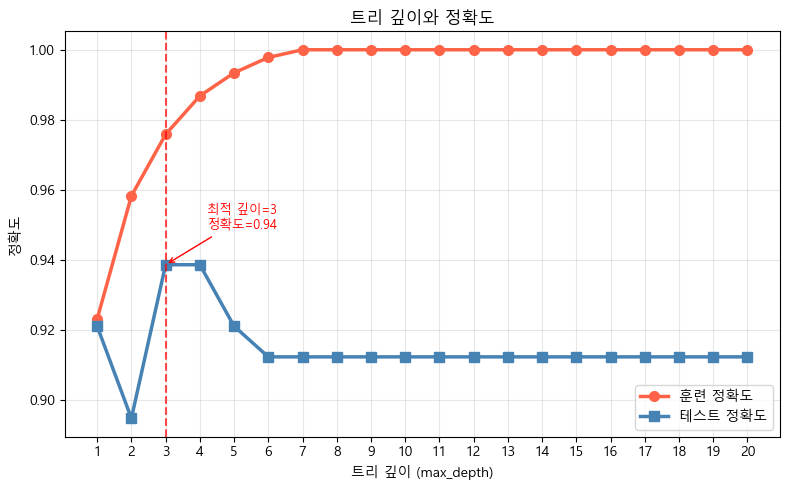

In [50]:
# 결정트리에서 최적 max_depth 탐색
# 데이터 불러오기
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print('=== 유방암 데이터셋 기본 정보 ===')
print(f'데이터 크기: {X.shape}')
print(f'클래스: {cancer.target_names}')
print('클래스 분포:')
for i, name in enumerate(cancer.target_names):
    count = np.sum(y == i)
    print(f'  {name}: {count}개 ({count/len(y)*100:.1f}%)')

# 학습/테스트 분리
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  
)

print('\n=== 데이터 분리 완료 ===')
print(f'학습 데이터: {X_train_c.shape}')
print(f'테스트 데이터: {X_test_c.shape}')

# 최적 max_depth 탐색하며 모델 훈련
depths       = range(1, 21)
train_scores = []
test_scores  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_c, y_train_c)
    train_scores.append(accuracy_score(y_train_c, dt.predict(X_train_c)))
    test_scores.append(accuracy_score(y_test_c,   dt.predict(X_test_c)))

best_depth = list(depths)[np.argmax(test_scores)] # 테스트 성적이 가장 좋은 깊이 번호
best_score = max(test_scores)                     # 그때의 최고 점수


# 최적 max_depth 출력
print('\n=== 최적 max_depth 탐색 완료 ===')        
print(f'최적 max_depth: {best_depth}  (테스트 정확도: {best_score:.2f})')

# 시각화 
plt.figure(figsize=(8, 5))
plt.plot(list(depths), train_scores, 'o-', color='tomato',    linewidth=2.5, markersize=7, label='훈련 정확도')
plt.plot(list(depths), test_scores,  's-', color='steelblue', linewidth=2.5, markersize=7, label='테스트 정확도')
plt.axvline(x=best_depth, color='red', linestyle='--', alpha=0.7)
plt.annotate(f'최적 깊이={best_depth}\n정확도={best_score:.2f}',
             xy=(best_depth, best_score),
             xytext=(best_depth + 1.2, best_score + 0.01),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')
plt.xlabel('트리 깊이 (max_depth)')
plt.ylabel('정확도')
plt.title('트리 깊이와 정확도')
plt.legend()
plt.xticks(list(depths))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 8-4. 정보이론 연습 문제

In [52]:
# ─── 연습 문제 IT-1 ──────────────────────────────────────────────────────────
# 아래 세 분포 중 엔트로피가 가장 높은 것은 무엇인가요?
# 직접 계산하고 이유를 설명해보세요.

dist_A = [0.5, 0.5]                    # 이진, 균등
dist_B = [0.9, 0.1]                    # 이진, 편향
dist_C = [0.25, 0.25, 0.25, 0.25]     # 4클래스, 균등
dist_D = [0.7, 0.1, 0.1, 0.1]         # 4클래스, 편향

# entropy() 함수를 사용해 각 분포의 엔트로피를 계산
# 엔트로피 함수 정
def entropy(probs) :
    return -sum(p * np.log2(p + 1e-12) for p in probs if p > 0)

# 각 분포의 엔트로피 계산
ent_A = entropy(dist_A)
ent_B = entropy(dist_B)
ent_C = entropy(dist_C)
ent_D = entropy(dist_D)

print('=== 분포별 엔트로피 계산 결과 ===')
print(f'분포 A (2클래스, 균등): {ent_A:.4f}')
print(f'분포 B (2클래스, 편향): {ent_B:.4f}')
print(f'분포 C (4클래스, 균등): {ent_C:.4f}')
print(f'분포 D (4클래스, 편향): {ent_D:.4f}')

# 엔트로피가 가장 큰 값 찾기
results = {'A': ent_A, 'B': ent_B, 'C': ent_C, 'D': ent_D}
max_dist = max(results, key=results.get)
print(f'\n-> 가장 엔트로피가 높은 분포는 [{max_dist}] 이며, 값은 {results[max_dist]:.4f} 입니다.')
print(f'-> 분포 [{max_dist}]의 엔트로피가 가장 높은 이유는 선택지가 가장 많고, 확률도 균등하여 불확실성이 가장 높기 때문입니다')

=== 분포별 엔트로피 계산 결과 ===
분포 A (2클래스, 균등): 1.0000
분포 B (2클래스, 편향): 0.4690
분포 C (4클래스, 균등): 2.0000
분포 D (4클래스, 편향): 1.3568

-> 가장 엔트로피가 높은 분포는 [C] 이며, 값은 2.0000 입니다.
-> 분포 [C]의 엔트로피가 가장 높은 이유는 선택지가 가장 많고, 확률도 균등하여 불확실성이 가장 높기 때문입니다


In [55]:
# ─── 연습 문제 IT-2 ──────────────────────────────────────────────────────────
# 다음 두 예측 결과 중 크로스 엔트로피 손실이 더 낮은 것은?
# 왜 그런지 설명해보세요.

# 실제 레이블 (3개 샘플, 클래스 0/1/2)
y_true_oh = [[1,0,0], [0,1,0], [0,0,1]]  # 원-핫 인코딩

# 두 모델의 예측 확률
pred_model1 = [[0.8, 0.1, 0.1],  # 샘플 1: 클래스 0 높게 예측 (정답 O)
               [0.2, 0.6, 0.2],  # 샘플 2: 클래스 1 높게 예측 (정답 O)
               [0.1, 0.2, 0.7]]  # 샘플 3: 클래스 2 높게 예측 (정답 O)

pred_model2 = [[0.5, 0.3, 0.2],  # 샘플 1: 확신이 낮은 예측
               [0.3, 0.4, 0.3],  # 샘플 2: 확신이 낮은 예측
               [0.2, 0.3, 0.5]]  # 샘플 3: 확신이 낮은 예측

# 각 모델의 크로스 엔트로피 손실을 계산
def cross_entropy(P, Q):
    return -sum(p * np.log(q + 1e-12) for p, q in zip(P, Q))

loss1 = np.mean([cross_entropy(p, q) for p, q in zip(y_true_oh, pred_model1)])
loss2 = np.mean([cross_entropy(p, q) for p, q in zip(y_true_oh, pred_model2)])

print('=== 크로스 엔트로피 계산 결과 ===')
print(f'Model 1 CE Loss: {loss1:.4f}')
print(f'Model 2 CE Loss: {loss2:.4f}')

# 엔트로피 손실이 더 낮은 값 찾기
results = {'Model 1': loss1, 'Model 2': loss2}
min_model = min(results, key=results.get)
print(f'\n-> 가장 엔트로피가 높은 분포는 [{min_model}] 이며, 값은 {results[min_model]:.4f} 입니다.')
print(f'-> 분포 [{min_model}]의 엔트로피 손실이 더 낮은 이유는 더 높은 확률을 부여하여 정답을 맞췄기 때문입니다. ')

=== 크로스 엔트로피 계산 결과 ===
Model 1 CE Loss: 0.3635
Model 2 CE Loss: 0.7675

-> 가장 엔트로피가 높은 분포는 [Model 1] 이며, 값은 0.3635 입니다.
-> 분포 [Model 1]의 엔트로피 손실이 더 낮은 이유는 더 높은 확률을 부여하여 정답을 맞췄기 때문입니다. 


In [58]:
# ─── 연습 문제 IT-3 ──────────────────────────────────────────────────────────
# D_KL(P||Q)와 D_KL(Q||P)의 차이를 계산하고
# KL Divergence가 왜 '거리(distance)'가 아닌지 설명해보세요.

P_ex = [0.8, 0.15, 0.05]
Q_ex = [0.1, 0.2,  0.7 ]

# kl_divergence 함수 정의
def kl_divergence(P, Q):
    return sum(p * np.log((p + 1e-12) / (q + 1e-12)) for p, q in zip(P, Q) if p > 0)

# D_KL(P||Q)과 D_KL(Q||P)의 차이 계산
kl_PQ = kl_divergence(P_ex, Q_ex)
kl_QP = kl_divergence(Q_ex, P_ex)

print('=== D_KL(P||Q)과 D_KL(Q||P) 계산 결과 ===')
print(f'D_KL(P||Q) = {kl_PQ:.4f}')
print(f'D_KL(Q||P) = {kl_QP:.4f}')

print('\n=== D_KL(P||Q)과 D_KL(Q||P)의 차이 ===')
print(f'차이: {abs(kl_PQ - kl_QP):.4f}')
print(f"-> D_KL(P||Q)과 D_KL(Q||P)이 달라 대칭성이 성립하지 않으므로 KL Divergence는 '거리(distance)'가 아닌 '정보량의 차이'를 나타냅니다.")


=== D_KL(P||Q)과 D_KL(Q||P) 계산 결과 ===
D_KL(P||Q) = 1.4884
D_KL(Q||P) = 1.6969

=== D_KL(P||Q)과 D_KL(Q||P)의 차이 ===
차이: 0.2085
-> D_KL(P||Q)과 D_KL(Q||P)이 달라 대칭성이 성립하지 않으므로 KL Divergence는 '거리(distance)'가 아닌 '정보량의 차이'를 나타냅니다.
